# Cálculo del espectro de transmisión teórico de un Cristal Magnónico 1D Reconfigurable Térmicamente usando el metodo de la matriz de transferencia estratificada bajo un modelo de reflexión por impedancia




## Ablación Láser

En el caso de la ablación láser o ataqe quimico la reflexión se calcula puramente a partir de la geometría del escalón físico:

$$\Gamma = \delta / (2d - \delta) $$

Sustituyendo los valores de la placa de YIG reportados (dPF = 8.3 μm y $\delta$=1.0 μm):

$$\Gamma = 1.0 / (2(8.3) - 1.0) = 1 / 15.6 \approx  0.0641 $$

Esto significa que el cristal grabado químicamente refleja un $\approx$ 6.41% de la amplitud de la onda en cada interfaz entre un surco y la película plana. Este 6.4% es el responsable de abrir los bandgaps de >20 dB que observamos en las gráficas.

## Perfil de temperatura

Para el caso óptico en el que el CM es reconfigurable termicamente, el grosor es constante, pero el vector de onda local $k(ω)$ cambia porque la magnetización de saturación $M_s$ cambia con la temperatura.

A medida que la temperatura aumenta localmente, la agitación térmica compite con el intercambio ferromagnético, reduciendo M_s. Lejos de la temperatura de Curie (que para el YIG es cercana a 550 K), este cambio se puede aproximar localmente de forma lineal:

$$ M_s(T) \approx M_s(T_0) - \alpha \Delta T  $$

Donde $\alpha$ es el coeficiente térmico de la magnetización y $\Delta T$ es el aumento de temperatura inducido por el láser.

$\alpha \approx $ de -4.5 a -5.0 Gauss/K.   o   $\approx$ -0.38 kA/(m·K).

La reflexión en este modelo es de origen puramente magnético/dieléctrico (análogo a un cambio de índice de refracción en óptica). En una línea de transmisión, la impedancia característica depende del vector de onda local. Por lo tanto, el coeficiente de reflexión en la frontera entre la zona oscura (fria) y la iluminada (caliente) se puede aproximar mediante el desacople de los vectores de onda:

$$  \Gamma_{term} = \frac{k_{frio} - k_{caliente} }{k_{frio} + k_{caliente}}       $$

Se observa que a diferencia del coefiente de reflexión geometrico, el térmico depende explicitamente de la frecuencia $\omega = 2 \pi f$ a la que se generan las ondas de espin.



Vamos a evaluar este valor para una frecuencia típica en la zona de propagación, f = 4.1 GHz, para observar como se compara con el valor del caso ablacionado/quimico.

**Parametros:**

Frecuencia:  $\omega = 2 \pi \times 4.1 $ rad/ns

Campo aplicado: $H_0 = 770$ Oe $⟹$ $\omega_H = 2\pi \times (2.8 \times 0.770) \approx 2\pi \times 2.156 $ rad/ns

Grosor: $d=8.3$ μm

#### Región Oscura (Fría):

$M_s = 1750 $ G $⟹$ $\omega_M \approx 2\pi \times 4.900 $ rad/ns


$k_{frio}(\omega) = - \frac{1}{2d} \ln [1+ \frac{4}{\omega_M^2} (\omega_H(\omega_H + \omega_M) ) - \omega^2  ]  \approx 186 $ rad/ cm


#### Región Iluminada (Caliente):

Asumimos un $\delta T = 20^∘ C$. De manera que

$M_s = 1750 - 4.75 (20) = 1655 G$ $⟹$ $\omega_M \approx 2\pi \times 4.634 $ rad / ns


Al evaluar la misma fórmula del vector de onda con este nuevo $\omega_M$ obtenemos:

$k_{caliente}(\omega) \approx 312$ rad / cm

#### Coeficiente de reflexión térmico

Sustituyendo nuestros dos vectores de onda obtenemos:

$$ \Gamma \approx - 0.253  $$

Un aumento de temperatura local de solo $20^∘ C$ genera un coeficiente de reflexión magnética de alrededor del 25.3%.

Esto implica que incluso un gradiente térmico muy sutil ($\Delta T = 6^∘ C$) generaría un salto de impedancia de $\approx$ 6%, igualando el rendimiento del cristal físico perforado.




In [2]:
import numpy as np
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")

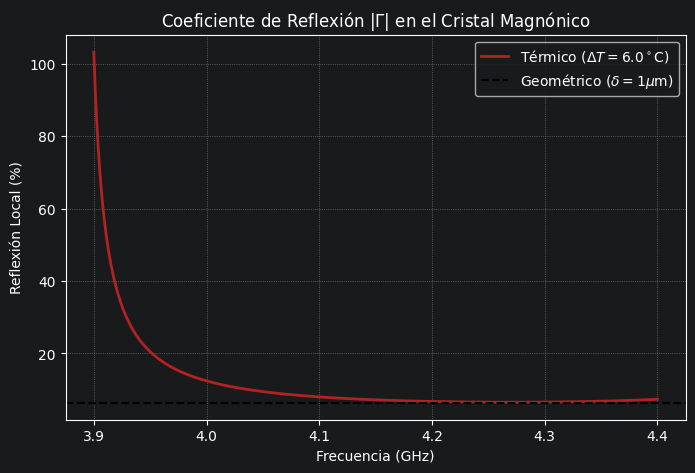

In [3]:
# =================================================================
# 1. PARÁMETROS DEL SISTEMA
# =================================================================

# Comparación de los coeficientes de reflexión entre el modelo de un CM ablasionado
# y uno inducido por un perfil de temperatura

# Parámetros Base
gamma = 2.8
H0 = 770.0
wH = 2 * np.pi * (gamma * H0 / 1000.0)
d = 8.3

# Magnetizaciones
Ms_frio = 1750.0
Delta_T = 6.0  # Gradiente de temperatura medido
Ms_caliente = Ms_frio - 4.75 * Delta_T

wM_frio = 2 * np.pi * (gamma * Ms_frio / 1000.0)
wM_cal = 2 * np.pi * (gamma * Ms_caliente / 1000.0)

def k_wave(w, wM):
    """Calcula el vector de onda dado una frecuencia y una magnetización"""
    arg = 1 + (4 / wM**2) * (wH * (wH + wM) - w**2)
    # Evitar valores inválidos fuera de la banda de propagación
    if arg <= 0:
        return np.nan
    return -(1 / (2 * d)) * np.log(arg)

# Rango de frecuencias (GHz)
f_array = np.linspace(3.9, 4.4, 400)
Gamma_therm = []

for f in f_array:
    w = 2 * np.pi * f
    k1 = k_wave(w, wM_frio)
    k2 = k_wave(w, wM_cal)

    if np.isnan(k1) or np.isnan(k2):
        Gamma_therm.append(np.nan)
    else:
        # Magnitud del salto de impedancia
        G = np.abs((k1 - k2) / (k1 + k2))
        Gamma_therm.append(G * 100) # En porcentaje

# Salto geométrico de referencia (Artículo Ordóñez)
Gamma_geom = (1.0 / (2 * 8.3 - 1.0)) * 100

# Gráfica
plt.figure(figsize=(8, 5))
plt.plot(f_array, Gamma_therm, color='firebrick', linewidth=2, label=f'Térmico ($\Delta T = {Delta_T}^\circ$C)')
plt.axhline(y=Gamma_geom, color='black', linestyle='--', label=f'Geométrico ($\delta = 1\mu$m)')

plt.title('Coeficiente de Reflexión $|\Gamma|$ en el Cristal Magnónico')
plt.xlabel('Frecuencia (GHz)')
plt.ylabel('Reflexión Local (%)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Espectro de transmisión téorico (caso ideal): Perfil de temperatura cuadrado (cambio abrupto)

En este escenario idealizado, asumimos que el arreglo óptico proyecta un patrón de luz perfecto y que el YIG tiene una conductividad térmica nula en el plano transversal, impidiendo que el calor se difunda. Esto genera un perfil térmico de escalón cuadrado.

In [3]:
# =================================================================
# 1. PARÁMETROS DEL SISTEMA
# =================================================================

# Parámetros magnéticos
gamma = 2.8      # Proporción giromagnética (MHz/Oe)
H0 = 770.0       # Campo magnético aplicado (Oe)
deltaH = 0.5     # Ancho de línea FMR (Oe)

Delta_T = 6.0  # Gradiente de temperatura medido
alpha = 4.75   # Coeficiente térmico de magnetización del YIG (Gauss / K)

Ms_frio = 1750.0      # Magnetización de saturación base (Gauss)
Ms_caliente = Ms_frio - alpha * Delta_T  # Aproximación lineal de la modificación de la magnetización

# Frecuencias angulares (en rad/ns para consistencia con um y ns)
# Dividimos entre 1000 para pasar de MHz a GHz (1 / 1 GHz ~ 1 ns)
wH = 2 * np.pi * (gamma * H0 / 1000.0)
wM_frio = 2 * np.pi * (gamma * Ms_frio / 1000.0)
wM_caliente = 2 * np.pi * (gamma * Ms_caliente / 1000.0)

# Parámetros geométricos-ópticos
d = 6.3          # Espesor constante de la película plana
Lfrio = 70.0      # Longitud de la región oscura (fria)
Lcaliente = 330.0        # Longitud de la región iluminada (caliente)
Nperiods = 12    # Número total de períodos

In [4]:
# =================================================================
# 2. FUNCIONES DE DISPERSIÓN Y ATENUACIÓN ESPACIAL
# =================================================================

def k_wave(w, wM):
    """Calcula el vector de onda real dado una frecuencia y una magnetización"""
    arg = 1 + (4 / wM**2) * (wH * (wH + wM) - w**2)
    # Evitar valores inválidos fuera de la banda de propagación
    if arg <= 0:
        return np.nan
    return -(1 / (2 * d)) * np.log(arg)

def v_group(w, wM):
    """Calcula la velocidad de grupo en um/ns"""
    k = k_wave(w, wM)
    return (wM**2 * d * np.exp(-2 * k * d)) / (4 * w)

def k_prime(w, wM):
    """Calcula la tasa de atenuación espacial k' en rad/um"""
    vg = np.abs(v_group(w, wM))

    # Dividimos entre 1000 para que quede  (rad / ns) / (um / ns) = rad / um
    # Al multiplicar por L en um nos queda el argumento de la exponencial en rad
    gamma_rad_ns = 2 * np.pi * (gamma * deltaH / 1000.0)
    return gamma_rad_ns / vg

In [5]:
# =======================================================================
# 3. CONSTRUCCIÓN DE LAS MATRICES DE TRANSFERENCIA
# =======================================================================

def GammaRef(w):
    """Coeficiente de reflexión por salto de impedancia"""
    k_frio = k_wave(w, wM_frio)
    k_caliente = k_wave(w, wM_caliente)

    return  abs((k_frio - k_caliente) / (k_frio + k_caliente))

def T_interface(nu, w):
    """Matriz de interfaz geométrica. nu=+1 (entrada), nu=-1 (salida)"""
    mat = np.array([
        [1.0, nu * GammaRef(w)],
        [nu * GammaRef(w), 1.0]
    ], dtype=complex)
    return (1.0 / (1.0 - nu * GammaRef(w))) * mat

def T_prop(w, wM, L):
    """Matriz de propagación con atenuación intrínseca"""
    k = k_wave(w, wM)
    kp = k_prime(w, wM)

    # Acumulación de fase y decaimiento de amplitud
    exp_minus = np.exp(-(1j * k - kp) * L)
    exp_plus  = np.exp((1j * k - kp) * L)

    return np.array([
        [exp_minus, 0.0],
        [0.0, exp_plus]
    ], dtype=complex)

def T_cell(w):
    """Multiplicación de matrices para una Celda Unidad completa"""
    t_pf = T_prop(w, wM_frio, Lfrio)
    t_in = T_interface(1, w)
    t_g  = T_prop(w, wM_caliente, Lcaliente)
    t_out = T_interface(-1, w)
    # @ -> multiplicación de matrices en numpy
    return t_pf @ t_in @ t_g @ t_out

def transmission_power(f_GHz):
    """Coeficiente de potencia transmitida Pw para el cristal de N periodos"""
    w = 2 * np.pi * f_GHz
    tc = T_cell(w)
    # Matriz elevada a la potencia N
    T_total = np.linalg.matrix_power(tc, Nperiods)
    T11 = T_total[0, 0]
    return 1.0 / (np.abs(T11)**2)  # P_tr = 1 / |T_11|^2 = 1 / |T_22|^2

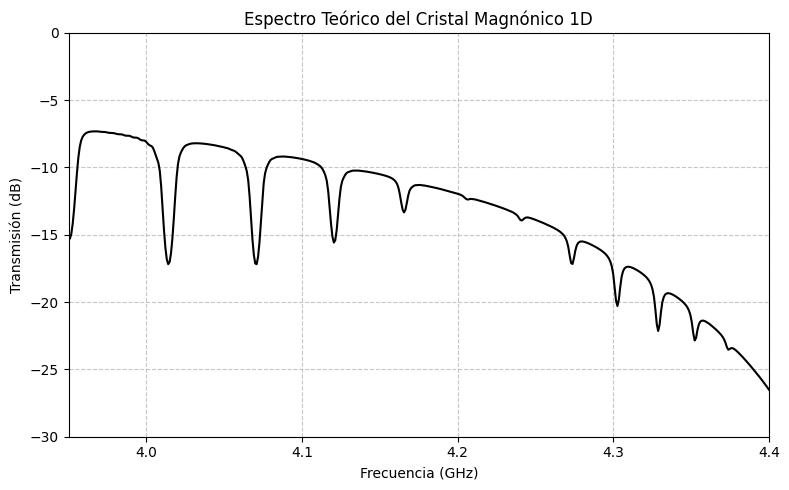

In [6]:
# =================================================================
# 4. CÁLCULO DEL ESPECTRO
# =================================================================

# Rango de frecuencias
f_min_ghz = 3.95
f_max_ghz = 4.4
f_array = np.linspace(f_min_ghz, f_max_ghz, 500)
trans_db = []

# Evaluar numéricamente cada punto
for f in f_array:
    p_w = transmission_power(f)
    trans_db.append(10 * np.log10(p_w))  # Escala de potencia en decibeles


plt.figure(figsize=(8, 5))
plt.plot(f_array, trans_db, color='black', linewidth=1.5)
plt.title('Espectro Teórico del Cristal Magnónico 1D')
plt.xlabel('Frecuencia (GHz)')
plt.ylabel('Transmisión (dB)')
plt.xlim(f_min_ghz, f_max_ghz)
plt.ylim(-30, 0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Espectro de transmisión téorico: Perfil de temperatura gaussiano (cambio difuso, modelo realista)

Dado que el gradiente de temperatura inducido por el láser no creará escalones rectangulares perfectos (debido a la difusión de temperatura por calor), para implementar un modelo téorico más realista debemos adaptar la formulación matricial anterior a un método de matriz de transferencia estratificado para simular un perfil de magnetización continuo (un thermal landscape) sinusoidal o gaussiano.

¿ cómo el suavizado en el perfil de Temperatura affecta las caracteristicas o presencia de los bandgaps ?


Para resolver esto numéricamente, vamos a discretizar la celda unidad de longitud $\Lambda$ en N "rebanadas" delgadas de ancho dx. En cada rebanada asumiremos que la temperatura y, por tanto, la magnetización $M_s$, es constante. Luego, multiplicaremos las matrices de todas las rebanadas en serie para construir la mega-matriz de la celda unidad:

$$ T_{cell} = \prod (T_{prop,j} \cdot T_{int,j → j+1}(\nu=1) \cdot T_{prop,j} \cdot T_{int,j → j+1}(\nu=-1)) $$

Al pasar de la rebanada j a la rebanada j+1 calcularemos un coeficiente de reflexión local Γ basándonos en el cambio del vector de onda:

$$  \Gamma_{term} = \frac{k_{frio} - k_{caliente} }{k_{frio} + k_{caliente} }    $$

**Perfil térmico gaussiano:** Si definimos el centro de la franja iluminada en la coordenada $x_c$​, el aumento de temperatura en cualquier punto x está dado por:

$$ \Delta T (x) = \Delta T_{max} \exp(- \frac{ (x-x_c)^2}{2 \sigma^2}) $$

Dado que la magnetización de saturación decrece linealmente con la temperatura: $ M_s(T(x)) = M_s(T_0) - \alpha \Delta T(x), el perfil de magnetización tomará exactamente la forma invertida del perfil térmico:

$$ M_s(x) = M_s(T_0) - (M_s(T_0) - M_s(T_{max}) ) \exp(- \frac{ (x-x_c)^2}{2 \sigma^2})$$

Si la termalización es muy fuerte (un $\sigma$ muy grande), las "colas" de la campana térmica podrían extenderse más allá de los bordes de la celda unidad (atravesando x=0 o x=$\Lambda$) y traslaparse con el calor del surco adyacente. Para modelar esto con rigor absoluto y evitar discontinuidades en las fronteras de nuestra celda, calcularemos la distancia periódica mínima entre cada punto x y el centro del láser $x_c$.

La gran ventaja matemática de la campana de Gauss es que nos permite controlar la amplitud (el aumento máximo de temperatura ΔT) y la anchura (qué tan rápido termaliza o decae el calor hacia las zonas oscuras) mediante el valor de la desviación estándar (σ).

Para un valor de $\sigma$ muy pequeño se obtendrán picos muy afilados que caen a temperatura ambiente casi inmediatamente al entrar a la zona oscura. Para un valor grande, las faldas de la campana térmica se ensanchan, levantando la temperatura base en la zona oscura.

Esta parametrización nos permite ver como la resolución del láser y la conductividad (disipación) térmica en la placa de YIG afectan las caracteristicas de los bandgaps (si los hay).

In [148]:
# =================================================================
# 1. PARÁMETROS DEL SISTEMA
# =================================================================

# Parámetros magnéticos
gamma = 2.8      # Proporción giromagnética (MHz/Oe)
H0 = 770.0       # Campo magnético aplicado (Oe)
deltaH = 0.5     # Ancho de línea FMR (Oe)

Delta_T = 6.0  # Pico de temperatura máximo
alpha = 3.93  # Coeficiente térmico de magnetización del YIG (Gauss / K)

Ms_frio = 1750.0      # Magnetización de saturación base (Gauss)
Ms_caliente = Ms_frio - alpha * Delta_T  # Aproximación lineal de la modificación de la magnetización

# Frecuencias angulares (en rad/ns para consistencia con um y ns)
# Dividimos entre 1000 para pasar de MHz a GHz (1 / 1 GHz ~ 1 ns)
wH = 2 * np.pi * (gamma * H0 / 1000.0)
wM_frio = 2 * np.pi * (gamma * Ms_frio / 1000.0)

# Parámetros geométricos-ópticos
d = 6.3          # Espesor constante de la película plana
Lfrio = 70.0      # Longitud de la región oscura (fria)
Lcaliente = 330.0        # Longitud de la región iluminada (caliente)
Lambda = Lfrio + Lcaliente   # Parámetro de red
Nperiods = 12    # Número total de períodos

# =================================================================
# PARÁMETROS DEL PERFIL GAUSSIANO (El control del calor)
# =================================================================
N_slices = 400  # Mayor resolución para capturar bien la campana
dx = Lambda / N_slices # longitud de cada rebanada

x_array = np.linspace(0, Lambda, N_slices, endpoint=False)
Ms_perfil = np.zeros(N_slices)

In [149]:
# Perfil Gaussiano
x_centro = Lfrio + (Lcaliente / 2.0) # Centro del haz láser (lo colocamos a la mitad de la franja iluminada)
sigma_termal = 5.0 # Factor de termalización (sigma).
for i, x in enumerate(x_array):
    # Calculamos la distancia al centro del láser.
    # Usamos la distancia periódica para que las colas de calor se envuelvan
    # correctamente si el calor invade las celdas vecinas.
    distancia = np.abs(x - x_centro)
    distancia_periodica = np.minimum(distancia, Lambda - distancia)

    # Amplitud de la campana en este punto x (de 0.0 a 1.0)
    perfil_gauss = np.exp(- (distancia_periodica**2) / (2 * sigma_termal**2))

    # Mapeamos la amplitud térmica a la magnetización
    Ms_perfil[i] = Ms_frio - (Ms_frio - Ms_caliente) * perfil_gauss

In [41]:
# Perfil continuo cuadrado
for i, x in enumerate(x_array):
    if x <= 69:
      Ms_perfil[i] = Ms_frio
    else:
      Ms_perfil[i] = Ms_caliente

In [153]:
# GENERACIÓN DEL PERFIL SUPER-GAUSSIANO (Aproximación Cuadrada)

w = Lcaliente / 2.0  # El semiancho de la zona iluminada (15 um)
P = 25                 # Orden P. Con P=20 será visualmente indistinguible de un cuadrado

for i, x in enumerate(x_array):
    distancia = np.abs(x - x_centro)
    distancia_periodica = np.minimum(distancia, Lambda - distancia)

    # La matemática del Super-Gaussiano
    perfil_super_gauss = np.exp(- (distancia_periodica / w)**(2 * P))

    # Mapeo a la magnetización
    Ms_perfil[i] = Ms_frio - (Ms_frio - Ms_caliente) * perfil_super_gauss

In [154]:
# =================================================================
# 2. FUNCIONES DE DISPERSIÓN Y ATENUACIÓN ESPACIAL LOCALES
# =================================================================

def w_M(Ms):
    """Frecuencia angular dada una magnetización Ms"""
    return 2 * np.pi * (gamma * Ms / 1000.0)

def k_wave(w, Ms):
    """Calcula el vector de onda real dado una frecuencia y una magnetización"""
    wM = w_M(Ms)
    arg = 1 + (4 / wM**2) * (wH * (wH + wM) - w**2)
    # Evitar valores inválidos fuera de la banda de propagación
    if arg <= 0:
        return np.nan
    return -(1 / (2 * d)) * np.log(arg)

def k_prime(w, Ms):
    """Calcula la tasa de atenuación espacial k' en rad/um"""
    # Primero calcula la velocidad de grupo en um/ns
    wM = w_M(Ms)
    k = k_wave(w, Ms)
    # Evitamos divergencias si k es puramente imaginario
    if np.iscomplex(k) and np.real(k) == 0:
        return 0.0
    vg = (wM**2 * d * np.exp(-2 * np.real(k) * d)) / (4 * w)

    # Dividimos entre 1000 para que quede  (rad / ns) / (um / ns) = rad / um
    # Al multiplicar por L en um nos queda el argumento de la exponencial en rad
    gamma_rad_ns = 2 * np.pi * (gamma * deltaH / 1000.0)
    return gamma_rad_ns / np.abs(vg)

# =================================================================
# FUNCIONES DE DISPERSIÓN: BVMSW (Modelo Vogel et al. 2015)
# =================================================================
def w_FMR_bvmsw(Ms):
    """ Frecuencia de Resonancia Ferromagnética """
    wm = w_M(Ms)
    return np.sqrt(wH * (wH + wm))

def vg_bvmsw(Ms):
    """ Velocidad de Grupo (Aproximación lineal) """
    wm = w_M(Ms)
    w_fmr = w_FMR_bvmsw(Ms)
    return -(1.0 / 4.0) * (wH * wm / w_fmr) * d

def k_wave_bvmsw(w, Ms):
    """ Vector de onda local (Despeje lineal) """
    w_fmr = w_FMR_bvmsw(Ms)
    vg = vg_bvmsw(Ms)
    # BVMSW existe para frecuencias w < w_FMR
    if w >= w_fmr:
        return 0.0 + 1j * 10.0
    return (w - w_fmr) / vg

def k_prime_bvmsw(w, Ms):
    """ Factor de atenuación intrínseca """
    vg = vg_bvmsw(Ms)
    gamma_rad_ns = 2 * np.pi * (gamma * deltaH / 1000.0)
    return gamma_rad_ns / np.abs(vg)

In [155]:
# =================================================================
# 3. MATRICES ESTRATIFICADAS (Modelo de reflexión por Impedancia)
# =================================================================

def T_interface(nu, Gamma):
    """Matriz de interfaz geométrica. nu=+1 (entrada), nu=-1 (salida)"""
    mat = np.array([
        [1.0, Gamma],
        [Gamma, 1.0]
        ], dtype=complex)
    return (1.0 / (1.0 - Gamma)) * mat

def T_cell_stratified_impedance(w, Ms_profile, dx, use_BVMSW = False):
    """
    Construye la matriz de la celda unidad multiplicando las N rebanadas
    usando la analogía de línea de transmisión (salto de impedancia).
    """
    N_slices = len(Ms_profile)
    T_total = np.eye(2, dtype=complex) # Matriz Identidad inicial
    nu_curr = 1

    for j in range(N_slices):
        Ms_curr = Ms_profile[j]

        if use_BVMSW:
            k_curr = k_wave_bvmsw(w, Ms_curr)
            kp_curr = k_prime_bvmsw(w, Ms_curr)
        else:
            k_curr = k_wave(w, Ms_curr)
            kp_curr = k_prime(w, Ms_curr)

        # 1. Matriz de propagación a través de la rebanada actual

        # Acumulación de fase y decaimiento de amplitud
        exp_minus = np.exp(-(1j * k_curr - kp_curr) * dx)
        exp_plus  = np.exp((1j * k_curr - kp_curr) * dx)

        T_prop = np.array([
            [exp_minus, 0.0],
            [0.0, exp_plus]
        ], dtype=complex)

        # 2. Matriz de interfaz
        # El índice circular (j+1) % N_slices conecta el final con el inicio de la celda
        Ms_next = Ms_profile[(j + 1) % N_slices]
        k_next = k_wave(w, Ms_next)

        # Cálculo del coeficiente de reflexión local (desacople de vectores de onda)
        # Se añade un pequeño epsilon para evitar división por cero accidental
        Gamma = (k_curr - k_next) / (k_curr + k_next)

        T_int_plus = T_interface(nu_curr, Gamma)

        # 3. Multiplicación de matrices

        T_total = T_total @ T_prop @ T_int_plus
        nu_curr = -1 * nu_curr

    return T_total

def transmission_power(f_GHz, Ms_profile, dx, use_BVMSW = False):
    """Coeficiente de potencia transmitida Pw para el cristal de N periodos"""
    w = 2 * np.pi * f_GHz
    tc = T_cell_stratified_impedance(w, Ms_profile, dx, use_BVMSW)
    # Matriz elevada a la potencia N
    T_total = np.linalg.matrix_power(tc, Nperiods)
    T11 = T_total[0, 0]
    return 1.0 / (np.abs(T11)**2)  # P_tr = 1 / |T_11|^2 = 1 / |T_22|^2


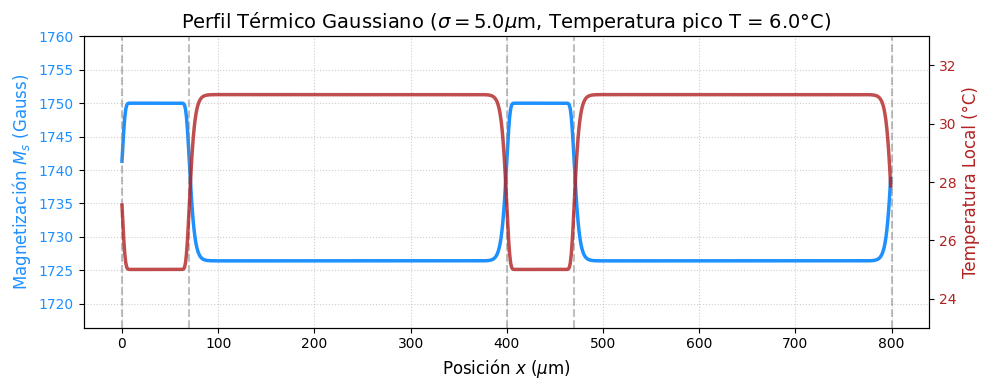

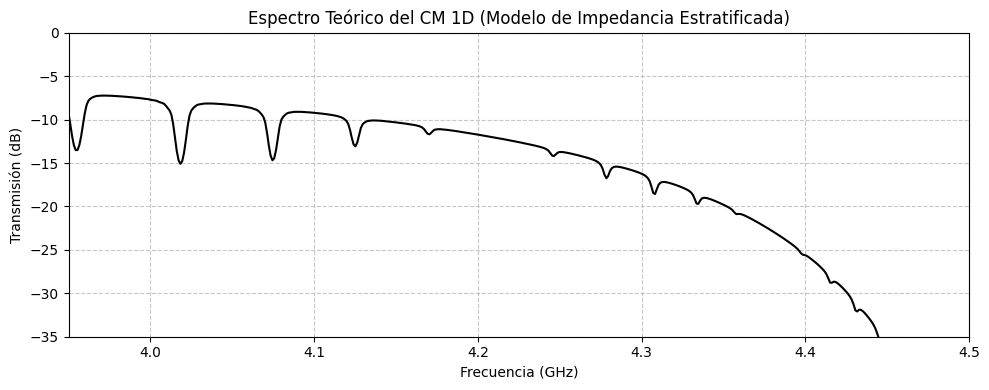

In [156]:
# =================================================================
# 4. EVALUACIÓN DEL ESPECTRO DE TRANSMISIÓN
# =================================================================

# Rango de frecuencias
f_min_ghz =3.95
f_max_ghz = 4.5
f_array = np.linspace(f_min_ghz, f_max_ghz, 500)
trans_db = [] # transmitancias en decibeles

# Evaluar numéricamente cada False
for f in f_array:
    p_w = transmission_power(f, Ms_perfil, dx, use_BVMSW= False)
    trans_db.append(10 * np.log10(p_w))  # Escala de potencia en decibeles


# =================================================================
# VISUALIZACIÓN DEL ARRAY GENERADO
# =================================================================

# Graficamos 2 celdas completas para ver la periodicidad
x_extendido = np.concatenate([x_array, x_array + Lambda])
Ms_extendido = np.concatenate([Ms_perfil, Ms_perfil])

# Calculamos el perfil térmico equivalente para el eje Y secundario
T_extendido = 25.0 + ((Ms_frio - Ms_extendido) / alpha) # Asumiendo T_amb = 25°C

fig, ax1 = plt.subplots(figsize=(10, 4))

# Eje principal: Magnetización (Ms)
color1 = 'dodgerblue'
ax1.plot(x_extendido, Ms_extendido, color=color1, linewidth=2.5)
ax1.set_xlabel('Posición $x$ ($\mu$m)', fontsize=12)
ax1.set_ylabel('Magnetización $M_s$ (Gauss)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(Ms_caliente - 10, Ms_frio + 10)

# Eje secundario: Temperatura
ax2 = ax1.twinx()
color2 = 'firebrick'
ax2.plot(x_extendido, T_extendido, color=color2, linewidth=2.5, alpha=0.8)
ax2.set_ylabel('Temperatura Local (°C)', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(25.0 - 2, 25.0 + Delta_T + 2)

# Líneas guía de la estructura geométrica
for limite in [0, Lfrio, Lambda, Lambda + Lfrio, 2*Lambda]:
    ax1.axvline(x=limite, color='gray', linestyle='--', alpha=0.5)

plt.title(f'Perfil Térmico Gaussiano ($\sigma = {sigma_termal} \mu$m, Temperatura pico T = {Delta_T}°C)', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# =================================================================
# 4. VISUALIZACIÓN DEL ESPECTRO DE TRANSMISIÓN
# =================================================================

plt.figure(figsize=(10, 4))
plt.plot(f_array, trans_db, color='black', linewidth=1.5)
plt.title('Espectro Teórico del CM 1D (Modelo de Impedancia Estratificada)')
plt.xlabel('Frecuencia (GHz)')
plt.ylabel('Transmisión (dB)')
plt.xlim(f_min_ghz, f_max_ghz)
plt.ylim(-35, 0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Espectro de transmisión téorico: Perfil de temperatura gaussiano para Backward Volume Spin Wave Mode (Basado en articulo de  M. Vogel y V. Chumak)

Repetimos el mismo análisis anterior para el mode de ondas de espin de Backward Volume.

Con base en el articulo de M. Vogel y V. Chumak: The
BVMSW dispersion relation—also accounting for the effective anisotropy—can be
approximated by

$$ \omega(k,T) = 2 \pi f (k,T) = \sqrt{\omega_H \left[ \omega_H + \omega_M(T)(\frac{1 - e^{-kd}}{kd}) - \omega_{anti} \right]} $$

Sin embargo, los autores notaron que para números de onda pequeños ($kd \ll 1$), se puede realizar una expansión en series de Taylor (una aproximación lineal). Esto transforma la ecuación anterior en una simple recta:

$$ \omega(k,T) \approx \omega_{FMR}(T) + v_g(T) k  $$

De aquí, despejar el vector de onda k es trivial:

$$ k(\omega, T) \approx \frac{\omega - \omega_{FMR}(T)}{v_g(T)} $$

Las piezas clave que definen esta recta son:

Frecuencia de Resonancia Ferromagnetica (FMR):

$$  \omega_{FMR}(T) = \sqrt{\omega_H (\omega_H + \omega_M(T) - \omega_{anti})} $$

Velocidad de Grupo:

$$v_g(T) = - \frac{1}{4} \frac{\omega_H \omega_M(T)}{\omega_{FMR}(T)} $$

el signo negativo indica que se trata de una onda "hacia atrás" (backward), donde la energía fluye en dirección opuesta a los frentes de fase.

Nota: Dado que BVMSW es una onda hacia atrás, su banda de propagación existe para frecuencias por debajo de la FMR, a diferencia de las MSSW que se propagan por encima de la FMR.


They divided the thermal pattern into N very narrow ranges with constant temperature. For each step two transfer matrices are computed:

$$  $$


In [ ]:
# =================================================================
# 1. PARÁMETROS BASE DEL SISTEMA Y PERFIL TÉRMICO
# =================================================================
gamma = 2.8
H0 = 770.0
wH = 2 * np.pi * (gamma * H0 / 1000.0)
d = 5.3
deltaH = 0.5

Lcaliente = 330.0
Lfrio = 70.0
Lambda = Lcaliente + Lfrio
Nperiods = 12

Ms_frio = 1750.0
Delta_T = 20.0
Ms_caliente = Ms_frio - 4.75 * Delta_T

w_ani = 0 #Tomamos w_ani igual a cero

# Perfil térmico Gaussiano
x_centro = Lfrio + (Lcaliente/2)
sigma_termal = 10.0
N_slices = 200
dx = Lambda / N_slices
x_array = np.linspace(0, Lambda, N_slices, endpoint=False)
Ms_profile = np.zeros(N_slices)

for i, x in enumerate(x_array):
    distancia = np.abs(x - x_centro)
    distancia_periodica = np.minimum(distancia, Lambda - distancia)
    perfil_gauss = np.exp(- (distancia_periodica**2) / (2 * sigma_termal**2))
    Ms_profile[i] = Ms_frio - (Ms_frio - Ms_caliente) * perfil_gauss

In [ ]:
# =================================================================
# 1. PARÁMETROS DEL SISTEMA (Vogel et al., 2015, Nature Physics)
# =================================================================
gamma = 2.8           # Proporción giromagnética (MHz/Oe)
H0 = 1797.0           # Campo magnético aplicado (Oe) equivalente a 143 kA/m
wH = 2 * np.pi * (gamma * H0 / 1000.0) # Frecuencia angular en rad/ns
d = 5.0               # Grosor de la película de YIG (um)
deltaH = 0.5          # Ancho de línea asumido (Oe)

# Geometría de la red
Lambda = 740.0        # Constante de red (um)
Nperiods = 5          # Número de franjas láser

# Parámetros Térmicos
T_background = 309.0  # Temperatura de fondo en la zona del cristal (K)
T_peak = 335.0        # Temperatura máxima en los picos (K)
Delta_T = T_peak - T_background # Salto térmico (K)

# Función de Magnetización de Saturación dependiente de la temperatura (en Gauss)
# 1759.3 G es la magnetización a 298 K. 3.93 es el coeficiente de decaimiento en Gauss/K
def Ms_T(T):
    return 1759.3 - 3.93 * (T - 298.0)

Ms_frio = Ms_T(T_background) # Magnetización base (en las zonas no iluminadas del cristal)
Ms_caliente = Ms_T(T_peak)   # Magnetización mínima (en el pico de luz)

# =================================================================
# 1B. GENERACIÓN DEL PERFIL TÉRMICO
# =================================================================
x_centro = Lambda / 2.0
sigma_termal = 30.0   # Ajustado para emular la anchura de las franjas térmicas en la Fig 1c
N_slices = 50
dx = Lambda / N_slices
x_array = np.linspace(0, Lambda, N_slices, endpoint=False)
Ms_profile = np.zeros(N_slices)

for i, x in enumerate(x_array):
    distancia = np.abs(x - x_centro)
    distancia_periodica = np.minimum(distancia, Lambda - distancia)
    # Perfil Gaussiano de calor
    perfil_gauss = np.exp(- (distancia_periodica**2) / (2 * sigma_termal**2))
    # Mapeo a la magnetización de saturación local
    Ms_profile[i] = Ms_frio - (Ms_frio - Ms_caliente) * perfil_gauss



In [ ]:
# =================================================================
# 1. PARÁMETROS DEL SISTEMA (Vogel et al., 2015, Nature Physics)
# =================================================================
gamma = 2.8           # Proporción giromagnética (MHz/Oe)
H0 = 1797.0           # Campo magnético aplicado (Oe) equivalente a 143 kA/m
wH = 2 * np.pi * (gamma * H0 / 1000.0) # Frecuencia angular en rad/ns
d = 8.3               # Grosor de la película de YIG (um)
deltaH = 0.5          # Ancho de línea asumido (Oe)

# Geometría de la red
Lambda = 400.0        # Constante de red (um)
Nperiods = 5          # Número de franjas láser

# Parámetros Térmicos
T_background = 309.0  # Temperatura de fondo en la zona del cristal (K)
T_peak = 335.0        # Temperatura máxima en los picos (K)
Delta_T = T_peak - T_background # Salto térmico (K)

# Función de Magnetización de Saturación dependiente de la temperatura (en Gauss)
# 1759.3 G es la magnetización a 298 K. 3.93 es el coeficiente de decaimiento en Gauss/K
def Ms_T(T):
    return 1759.3 - 3.93 * (T - 298.0)

Ms_frio = Ms_T(T_background) # Magnetización base (en las zonas no iluminadas del cristal)
Ms_caliente = Ms_T(T_peak)   # Magnetización mínima (en el pico de luz)

# =================================================================
# 1B. GENERACIÓN DEL PERFIL TÉRMICO
# =================================================================
x_centro = Lambda / 2.0
sigma_termal = 70.0   # Ajustado para emular la anchura de las franjas térmicas en la Fig 1c
N_slices = 50
dx = Lambda / N_slices
x_array = np.linspace(0, Lambda, N_slices, endpoint=False)
Ms_profile = np.zeros(N_slices)

for i, x in enumerate(x_array):
    distancia = np.abs(x - x_centro)
    distancia_periodica = np.minimum(distancia, Lambda - distancia)
    # Perfil Gaussiano de calor
    perfil_gauss = np.exp(- (distancia_periodica**2) / (2 * sigma_termal**2))
    # Mapeo a la magnetización de saturación local
    Ms_profile[i] = Ms_frio - (Ms_frio - Ms_caliente) * perfil_gauss

